In [1]:
%%html

<!-- styles d'affichage -->
<style>
    .section_div {
        width:70%;
        height:1.5px;
        border:none;
        color:black;
        background-color:black;
        margin: auto;
        margin-top: 0px;
        margin-bottom: 0px;
    }

    .answer {
        color:blue;
    }

    .question {
        color:red;
    }

    .note {
        color:green;
        font-weight: bold;
    }
</style>

In [2]:
#
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [3]:
#
# import utilitaires
#
%matplotlib inline

import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pathlib import Path
from pprint import pprint
from tqdm.notebook import tqdm

In [4]:
#
# import package develope pour le projet
#
import ffury
from ffury.configs import load_config, DEFAULT_CONFIG_FILE

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

# load dataset BirdCLEF
raw_df = pd.read_csv(config.get_dataset_raw_filename())

In [5]:
print("Information sur le data:", config.dataset.data_description_url)

Information sur le data: https://www.kaggle.com/competitions/birdclef-2023/data


In [6]:
print("Dataset shape:", raw_df.shape)

print()

print("Types")
display(raw_df.dtypes.to_frame().T)

Dataset shape: (16941, 12)

Types


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename
0,object,object,object,float64,float64,object,object,object,object,float64,object,object


In [7]:
#
# secondary_labels et type sont des listes
# valider que le parsing est bien ce qu'on pense
#
print("Type element 'secondary_labels':", type(raw_df.loc[0, "secondary_labels"]))
print("Type element 'type':", type(raw_df.loc[0, "type"]))

Type element 'secondary_labels': <class 'str'>
Type element 'type': <class 'str'>


<div class="answer">

On peut voir que la lecture du .csv n'est pas correcte. On devrait avoir une liste.

In [8]:
#
# corriger secondary_labels et type; ils sont des listes
#
if isinstance(raw_df.loc[0, "secondary_labels"], str):
    from ast import literal_eval

    raw_df["secondary_labels"] = raw_df["secondary_labels"].apply(literal_eval)
    raw_df["type"] = raw_df["type"].apply(literal_eval)

print()

print("Affichage succint")
display(raw_df.head())


Affichage succint


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename
0,abethr1,[],[song],4.3906,38.2788,Turdus tephronotus,African Bare-eyed Thrush,Rolf A. de By,Creative Commons Attribution-NonCommercial-Sha...,4.0,https://www.xeno-canto.org/128013,abethr1/XC128013.ogg
1,abethr1,[],[call],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,3.5,https://www.xeno-canto.org/363501,abethr1/XC363501.ogg
2,abethr1,[],[song],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,3.5,https://www.xeno-canto.org/363502,abethr1/XC363502.ogg
3,abethr1,[],[song],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,5.0,https://www.xeno-canto.org/363503,abethr1/XC363503.ogg
4,abethr1,[],"[call, song]",-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,4.5,https://www.xeno-canto.org/363504,abethr1/XC363504.ogg


Stat. generale pour 'type'


,count,mean,std,min,25%,50%,75%,max
0,399.0,63.255639,506.758959,1.0,1.0,1.0,2.0,6808.0


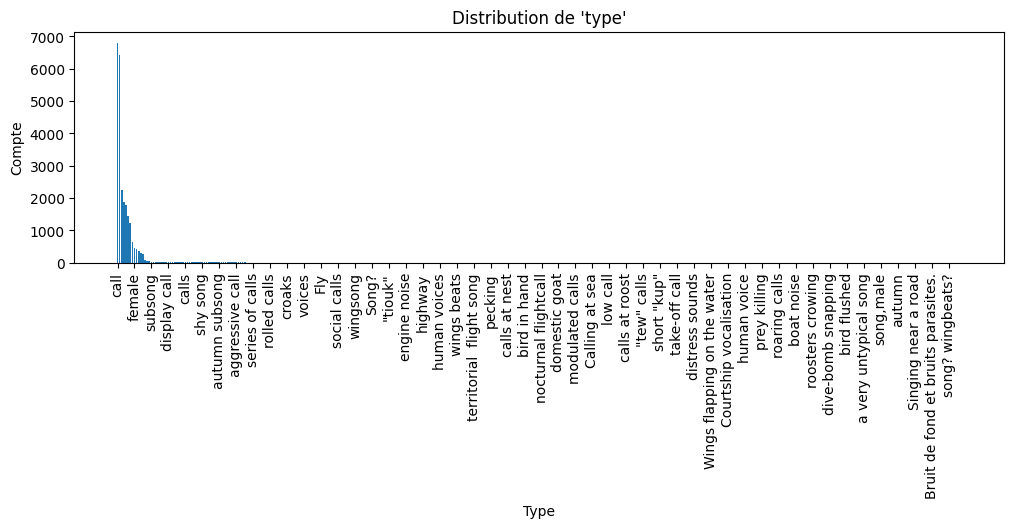

In [9]:
#
# examiner la distribution dans type
#
from itertools import islice

# calculer histogram
def type_histogram(types_, hist_dict):
    for t in types_:
        if t in hist_dict:
            hist_dict[t] += 1
        else:
            hist_dict[t] = 1

hist_dict = {}
raw_df["type"].apply(type_histogram, args=(hist_dict,))

# convertir en Series pandas (simplifie extraction statistiques)
hist_df =  pd.Series(data=hist_dict.values(), index=hist_dict.keys())

# afficher quelques stats
print("Stat. generale pour 'type'")
display(hist_df.describe().to_frame().T)

# afficher histogramme - ne garder que quelques lables car 
# il n'y en a trop pour etre visialise
count = len(hist_dict)

# aficher 1 type sur 8
step = 8

sorted_hist = sorted(hist_dict.items(), key=lambda x: x[1], reverse=True)
sorted_hist = {k:v for k, v in sorted_hist}

plt.figure(figsize=(12, 3))
plt.bar([i for i in range(count)], sorted_hist.values())

plt.gca().set_xticks([i for i in range(0, count, step)])
plt.gca().set_xticklabels([k for k in islice(sorted_hist.keys(), 0, count, step)], rotation=90)

plt.xlabel("Type")
plt.ylabel("Compte")
plt.title("Distribution de 'type'")
plt.show()

<div class="answer">

* 16941 echantillons
* 12 variables. Selon les informations trouvees via l'url et un examin visuel, les variables interessantes sont:
    - **primary_label**: identification de l'oiseau
    - **latitude** & **longitude**: coordonnes de l'enregistrement audio (garde pour usage eventuel)
    - **filename**: nom du fichier audio
    - **url**: url sur informations complementaires. Bien qu'utile, juge non necessaire puisque audio est deja present dans les donnes et images/metadata sont aussi disponible via primary_label.
    - **common_name**: utile pour interpretation des resultats mais non necessaire.
    - **rating**: evaulation de la qualite des fichiers audio. Pourrait etre utile pour filtrer davantage.
* les variables sont en fait des fichiers audio (donnees de type numerique) augmentees avec les latitudes & longitudes (donnees de type numerique) et quelques metadata (donnees de type categorielles)
* la variable cible est categorique

In [10]:
#
# ne garder que les attributs d'interets
#
data_df = raw_df[[
    "common_name",
    "primary_label", 
    "latitude", 
    "longitude", 
    "rating", 
    "filename"
]]
print("Attributs d'interet")
display(data_df.head())

Attributs d'interet


,common_name,primary_label,latitude,longitude,rating,filename
0,African Bare-eyed Thrush,abethr1,4.3906,38.2788,4.0,abethr1/XC128013.ogg
1,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,3.5,abethr1/XC363501.ogg
2,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,3.5,abethr1/XC363502.ogg
3,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,5.0,abethr1/XC363503.ogg
4,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,4.5,abethr1/XC363504.ogg


In [11]:
#
# explorer les valeurs manquantes
#
na_indices = data_df.isna()
na_rows = na_indices.any(axis=1)
na_num = na_rows.sum()

print(f"Quantite de valeurs manquantes: {na_num} ({na_num / data_df.shape[0] % 100:0.2f}%)")

print("Quelques valeurs manquantes")
display(data_df[na_rows].head())

Quantite de valeurs manquantes: 227 (0.01%)
Quelques valeurs manquantes


,common_name,primary_label,latitude,longitude,rating,filename
10,African Bare-eyed Thrush,abethr1,NaN,NaN,4.0,abethr1/XC585802.ogg
220,African Emerald Cuckoo,afecuc1,NaN,NaN,2.5,afecuc1/XC118454.ogg
913,Barn Swallow,barswa,NaN,NaN,1.0,barswa/XC169360.ogg
914,Barn Swallow,barswa,NaN,NaN,1.0,barswa/XC171221.ogg
916,Barn Swallow,barswa,NaN,NaN,3.0,barswa/XC171624.ogg


<div class="answer">

* Inspection dans .csv source montre bien que les valeurs sont manquantes
* Comme il n'y en a que tres peut, on les enleves

In [12]:
#
# Enlever NA
#
print("Shape avant:", data_df.shape)
valid_data_df = data_df[~na_rows]
print("Shape apres:", valid_data_df.shape)

Shape avant: (16941, 6)
Shape apres: (16714, 6)


In [13]:
#
# explorer doublons
#
dup_rows = valid_data_df.duplicated()
dup_num = dup_rows.sum()

print("Quantite de doublons:", dup_num)

Quantite de doublons: 0


In [14]:
#
# examiner distribution primary_label (espece)
#
unique_bird = valid_data_df.value_counts("primary_label")
print("Nombre d'especes:", unique_bird.shape[0])

Nombre d'especes: 264


<div class="answer">

* 264 correspond au nombres d'especes attendu dans le dataset (selon description de la competition)

In [15]:
#
# remettre les index comme une suite d'entiers consecutifs
# facilite l'indexation
#
valid_data_df.reset_index(inplace=True, drop=True)

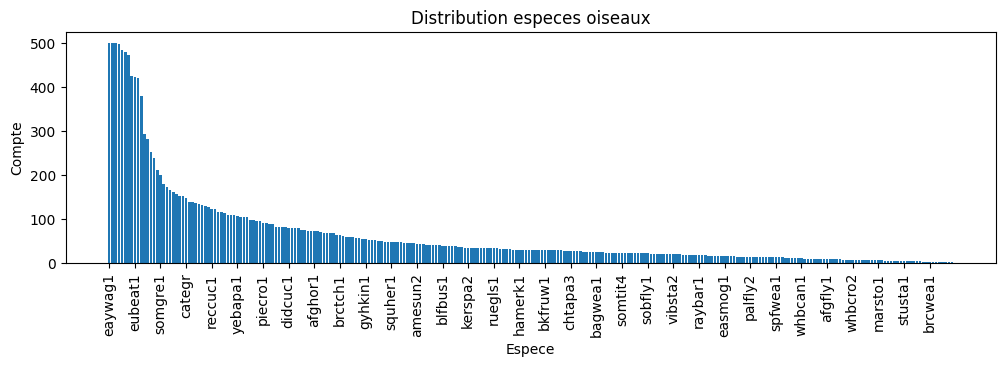

,count,mean,std,min,25%,50%,75%,max
count,264.0,63.310606,96.99807,1.0,14.0,29.5,70.25,500.0


In [16]:
plt.figure(figsize=(12, 3))

count = unique_bird.shape[0]
step = 8

plt.bar([i for i in range(count)], unique_bird.values)

plt.gca().set_xticks([i for i in range(0, count, step)])
plt.gca().set_xticklabels([unique_bird.index[i] for i in range(0, count, step)], rotation=90)

plt.xlabel("Espece")
plt.ylabel("Compte")
plt.title("Distribution especes oiseaux")
plt.show()

print()

display(unique_bird.to_frame().describe().T)

<div class="answer">

* distribution tres mal balancee; on regarde le champs **rating** pour voir on peut l'utiliser pour filtrer et avoir un data plus balance.

In [17]:
#
# extraire sampling rate et duree des fichiers audios
# les resultats sont cacher; mettre FORCE_PROCESS_AUDIO_STATS a True pour recalculer
#
FORCE_PROCESS_AUDIO_STATS = False

filename = Path.joinpath(config.paths.DATA_RAW_DIR, "audio_stats.csv")

if FORCE_PROCESS_AUDIO_STATS or not Path(filename).is_file():
    selected_audio = valid_data_df[:]

    audio_data = []
    for i in tqdm(range(len(selected_audio))):
        audio_filename = selected_audio.loc[i, "filename"]
        filename = config.get_audio_filename(filename)
        y, sr = rosa.load(filename)
        audio_data.append( [sr, len(y), len(y) / sr] )

    audio_df = pd.DataFrame(data=audio_data, columns=["SR", "Samples", "Duration"])

    stats_df = pd.concat([selected_audio[["common_name", "filename", "rating"]], audio_df], axis=1)
    stats_df.to_csv(filename, index=False)
else:
    stats_df = pd.read_csv(filename)

In [18]:
#
# analyser stats generales par rating
#
groups = group_stats_df = stats_df.iloc[:,-4:].groupby(["rating"])
groups = groups.agg({"SR": [("Min", lambda x: x.min()),
                            ("Max", lambda x: x.max()),
                            ("Unique", lambda x: len(x.unique()))],
                    "Duration": [("Q1", lambda x: x.quantile(0.25)),
                                 ("Q2", lambda x: x.quantile(0.50)),
                                 ("Q3", lambda x: x.quantile(0.75)),
                                 ("Mean", lambda x: x.mean()),
                                 ("Min", lambda x: x.min()),
                                 ("Max", lambda x: x.max())]})
print("Stats sommaire par rating")
display(groups)

Stats sommaire par rating


SR                 Duration                                   \
          Min    Max Unique         Q1         Q2         Q3       Mean   
rating                                                                    
0.0     22050  22050      1  12.255023  21.174558  41.086429  46.267426   
0.5     22050  22050      1  11.245612  19.761633  30.099592  25.171340   
1.0     22050  22050      1   6.974694  12.042063  23.032041  21.926301   
1.5     22050  22050      1  11.768073  21.655510  40.918798  33.269204   
2.0     22050  22050      1   8.262007  16.507528  30.739603  28.368574   
2.5     22050  22050      1  14.347721  26.004943  45.432188  41.452634   
3.0     22050  22050      1   9.456247  18.124490  35.088673  29.204368   
3.5     22050  22050      1  18.514286  31.359569  55.223152  51.367118   
4.0     22050  22050      1  11.781224  22.099002  40.946939  36.311230   
4.5     22050  22050      1  21.786168  37.041338  66.670692  63.397450   
5.0     22050  22050      1  12.936009  26.220023  48.364501  40.563634   

                               
             Min          Max  
rating                         
0.0     0.940408   873.299637  
0.5     3.082449    99.360000  
1.0     1.253878   145.893016  
1.5     1.752018   452.022041  
2.0     0.966576   395.088027  
2.5     0.864036  2043.167347  
3.0     0.816009   551.262041  
3.5     1.253878  2373.528027  
4.0     0.548027  1787.846576  
4.5     2.280000  1380.022041  
5.0     0.792018  1144.032018

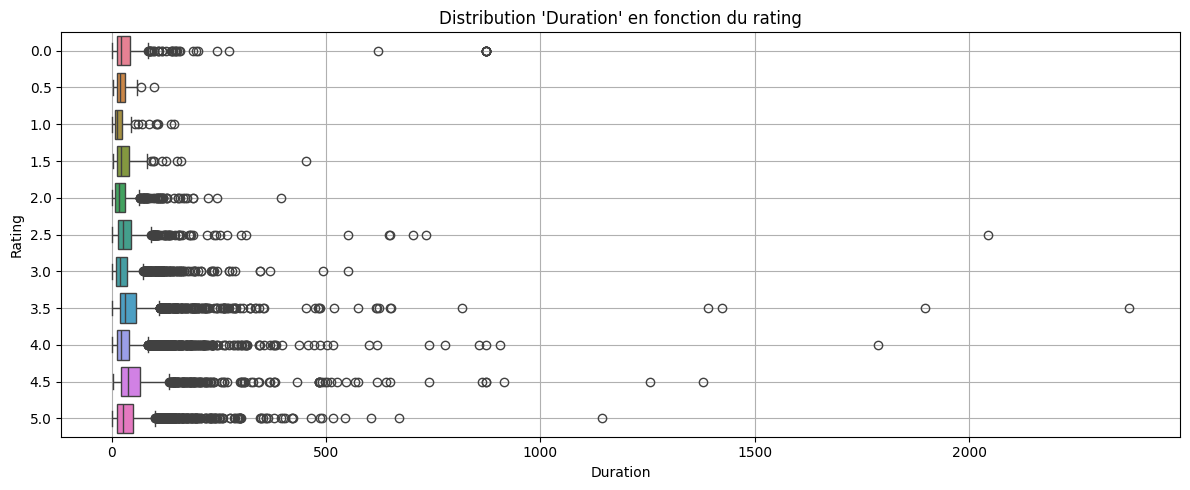

In [19]:
import seaborn as sns

duration_dict = {}
for i, g in enumerate(group_stats_df.groups):
    data = group_stats_df.get_group((g,))
    duration_dict[str(g)] = data["Duration"]

plt.figure(figsize=(12, 5))
sns.boxplot(duration_dict, orient="h", ax=plt.gca())
plt.grid()
plt.title("Distribution 'Duration' en fonction du rating")
plt.xlabel("Duration")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

<div class="answer">

* On constate qu'il n'y a que 1 seul sampling rate
* La duree des clip audios varie enormement. Clips avec rating bas semblent avoir moins d'outliers sur les clips longs. Distributions generales restent tout de meme similaire entre les ratings.

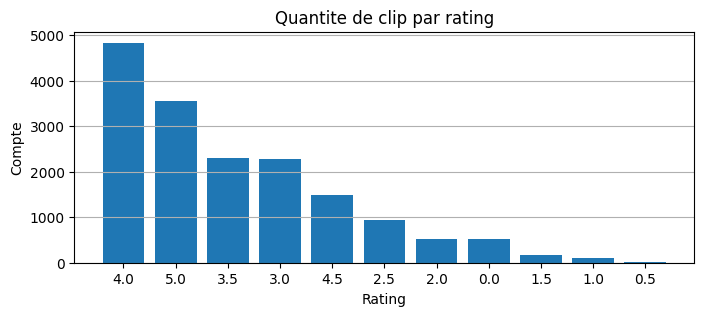

In [20]:
clip_count_df = stats_df["rating"].value_counts()

plt.figure(figsize=(8, 3))
plt.bar([str(i) for i in clip_count_df.index], clip_count_df.values)
plt.xlabel("Rating")
plt.ylabel("Compte")
plt.title("Quantite de clip par rating")
plt.grid(axis="y")
plt.show()

<div class="answer">

* Relativement peu de clips avec bas ratings
* Bien que suggestif, regardons qualite audio par rating.

In [21]:
MIN_RATING = 0.0
MAX_RATING = 2.0
viz_data = (raw_df["rating"] <= MAX_RATING) & (raw_df["rating"] >= MIN_RATING)
viz_data = raw_df[ viz_data ]
viz_data.reset_index(inplace=True)

print(f"Nombre de clips avec rating [{MIN_RATING}, {MAX_RATING}]:", viz_data.shape[0])

Nombre de clips avec rating [0.0, 2.0]: 1361


In [22]:
import librosa as rosa
from copy import copy
from IPython.display import Audio
from ipywidgets import Output, Layout, VBox, HBox, HTML

def melspectrogram(y, sr, **kwargs):
    # besoin de passer certains parametres entre melspectrogram()
    # et specshow() pour matcher timeline
    mel_kwargs = copy(kwargs)
    display_kwargs = {}

    if "n_fft" in kwargs:
        mel_kwargs["n_fft"] = math.ceil(kwargs["n_fft"] * sr)
        display_kwargs["n_fft"] = mel_kwargs["n_fft"]

    if "hop_length" in kwargs:
        mel_kwargs["hop_length"] = math.ceil(kwargs["hop_length"] * sr)
        display_kwargs["hop_length"] = mel_kwargs["hop_length"]

    # predire lwidth du spectrogram
    # mel_dim = math.ceil(len(y) / mel_kwargs["hop_length"])

    S = rosa.feature.melspectrogram(y=y, sr=sr, **mel_kwargs)
    S_db = rosa.power_to_db(S, ref=np.max)

    return S_db, display_kwargs

def get_display_outputs(index, figsize=None, **melspectrogram_kwargs):
    filename = config.get_audio_filename(raw_df.loc[index, "filename"])
    y, sr = rosa.load(filename)

    waveform = Output()
    with waveform:
        fig = plt.figure(figsize=figsize)
        rosa.display.waveshow(y,
                              sr=sr,
                              ax=plt.gca())
        plt.xlabel("")
        plt.close()

        display(fig)

    spectrogram = Output()
    with spectrogram:
        fig = plt.figure(figsize=figsize)

        S_db, display_kwargs = melspectrogram(y, sr, **melspectrogram_kwargs)
        rosa.display.specshow(S_db,
                              x_axis='time',
                              y_axis='mel',
                              sr=sr,
                              ax=plt.gca(),
                              **display_kwargs)
        plt.xlabel("")
        plt.close()

        display(fig)

    player = Output()
    with player:
        display(Audio(data=y, rate=sr))

    header = Output()
    with header:
        species = raw_df.loc[index, 'common_name']
        rating = raw_df.loc[index, 'rating']
        html = HTML(f"{species} - index {index} - rating {rating}")
        display(html)

    hb = HBox([waveform, spectrogram, player], 
              layout=Layout(width="100%", align_items="center"))

    vb = VBox([header, hb], 
              layout=Layout(height="100%", align_items="center", padding="10px 0 0 0"))

    return vb

def visualize_audio_from_raw_df(indices, figsize=None, **melspectrogram_kwargs):
    rows = []
    for i, index in enumerate(indices):
        row = get_display_outputs(index,
                                  figsize=figsize,
                                  **melspectrogram_kwargs)
        rows.append(row)
    display(VBox(rows))

def visualize_audio_from_viz_data(ids, figsize=None, **melspectrogram_kwargs):
    indices = [viz_data.loc[id, "index"] for id in ids]
    visualize_audio_from_raw_df(indices, figsize=figsize, **melspectrogram_kwargs)

#
# aide melspectrogram: https://tinyurl.com/3vf92xvx
#
STFT_FRAME_SIZE_MS = 12.5 / 1000 # ms
STFT_WINDOW_SIZE_MS = 2 * STFT_FRAME_SIZE_MS # ms

if False:
    # visualization random de viz_data
    visualize_audio_from_viz_data(np.random.randint(0, viz_data.shape[0], 5),
                                  figsize=(10, 4),
                                  n_fft=STFT_WINDOW_SIZE_MS, # ms
                                  hop_length=STFT_FRAME_SIZE_MS, # ms
                                  n_mels=128,
                                  fmin=0,
                                  fmax=8192)
else:
    # visulalisation specifique de raw_df
    # exemple de "mauvaise" qualite
    visualize_audio_from_raw_df([3038, 4845, 3870, 8991, 7483, 14548, 15518, 5197, 9224, 6329, 7145, 234, 7850, 3393],
                                figsize=(10, 4),
                                n_fft=STFT_WINDOW_SIZE_MS, # ms
                                hop_length=STFT_FRAME_SIZE_MS, # ms
                                n_mels=128,
                                fmin=0,
                                fmax=8192)

<div class="answer">

* **rating** semble etre synonyme d'un bruit de fond tres present par rapport au chant d'oiseau. Nous retrouvons ce cas un peu partout dans les divers clips peu importe le rating. Noter que notre manque de connaissance dans le domaine ne nous permets pas d'aller au dela de ce constat. Comme il n'y a pas enormement d'elements dans l'interval \[2.0, 0.0\], nous decidons de les enlevers.
* Les clips trop courts ne sont pas tres utiles. La literature semble suggerer des segments audio de 3 secondes.

In [23]:
final_data = (valid_data_df["rating"] > 2.0) & (stats_df["Duration"] >= 3.0)
final_data_df = valid_data_df[ final_data ].copy()
final_data_df.drop(columns=["rating"], inplace=True, errors="ignore")

print("# elements avant filtrage:", valid_data_df.shape[0])
print("# elements apres filtrage:", final_data_df.shape[0])
print("Attributs retenus:", final_data_df.columns.values)

print()

# sauvegarde du traitement
filename = Path.joinpath(config.paths.DATA_DIR, "data_raw.csv")
print("Sauvegarde de l'exploration:", filename)
final_data_df.to_csv(filename, index=False)

# elements avant filtrage: 16714
# elements apres filtrage: 15136
Attributs retenus: ['common_name' 'primary_label' 'latitude' 'longitude' 'filename']

Sauvegarde de l'exploration: /Users/jfgagnon/Projects/FeatheredFury/configs/../data/data_raw.csv
